# Narrative Miners: Uncover the Stories That Drive Markets

## Automated Analysis of Market Narratives Across Multiple Document Sources

## Why It Matters

Understanding how market narratives emerge and evolve across different information sources is crucial for investment decision-making, but manually tracking narrative development across scattered news coverage, earnings calls, and regulatory filings is time consuming. Investment decisions need systematic analysis of narrative progression to identify emerging trends and timing patterns.

## What It Does

The `NarrativeMiner` class in the bigdata-research-tools package systematically tracks narrative evolution across multiple document types using unstructured data from news, transcripts, and filings. Built for analysts, portfolio managers, and investment professionals, it transforms scattered narrative signals into quantified trend intelligence and identifies timing patterns across different information sources.

## How It Works

The `NarrativeMiner` combines **multi-source content retrieval**, **temporal narrative tracking**, and **cross-source comparative analysis** to deliver:

- **Cross-document narrative mapping** across news media, earnings calls, and SEC filings
- **Temporal evolution tracking** showing how narratives develop and change over time across sources
- **Intensity measurement** quantifying narrative prevalence and significance across document types

## A Real-World Use Case

This cookbook demonstrates the complete workflow through analyzing "AI Bubble Concerns" narrative as it emerges and evolves across news, earnings calls, and regulatory filings, highlighting the difference between public discourse and corporate communications.

## Setup and Imports

## Async Compatibility Setup

**Run this cell first** - Required for Google Colab, Jupyter Notebooks, and VS Code with Jupyter extension:

### Why is this needed?

Interactive environments (Colab, Jupyter) already have an asyncio event loop running. When bigdata-research-tools makes async API calls (like to OpenAI), you'll get this error without nest_asyncio:

```
RuntimeError: asyncio.run() cannot be called from a running event loop
```

The `nest_asyncio.apply()` command patches this to allow nested event loops.

💡 **Tip**: If you're unsure which environment you're in, just run the cell below - it won't hurt in any environment!

In [1]:
import datetime
start = datetime.datetime.now()

try:
    import asyncio
    asyncio.get_running_loop()
    import nest_asyncio; nest_asyncio.apply()
    print("✅ nest_asyncio applied")
except (RuntimeError, ImportError):
    print("✅ nest_asyncio not needed or not available")

✅ nest_asyncio applied


## Environment Setup

The following cell configures the necessary path for the analysis

In [2]:
import os
import sys

current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.append(current_dir)
print(f"✅ Local environment setup complete")

✅ Local environment setup complete


## Import Required Libraries

Import the core libraries needed for narrative mining analysis, including the custom visualization and analysis tools.

In [3]:
from IPython.display import display, HTML, IFrame
import pandas as pd
from pandas import merge

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
import warnings

from src.tool import (
    load_results, 
    extract_narrative_insights,
    create_source_summary,
    display_sample_data,
    visualize_cross_source_narratives, 
    visualize_news_narrative_breakdown
)

from bigdata_research_tools.workflows.narrative_miner import NarrativeMiner
from bigdata_research_tools.excel import ExcelManager
from bigdata_client import Bigdata
from bigdata_client.daterange import RollingDateRange
from bigdata_client.models.sources import Source
from bigdata_client.models.search import DocumentType

## Optional: Plotly Display Configuration

For better visualization rendering, you can also set the Plotly renderer:

In [4]:
import plotly
import plotly.graph_objects as go
import plotly.io as pio

# Try to detect the environment and set appropriate renderer
try:
    # Check if we're in JupyterLab
    import os
    if 'JUPYTERHUB_SERVICE_PREFIX' in os.environ or 'JPY_SESSION_NAME' in os.environ:
        pio.renderers.default = 'jupyterlab'
        print("✅ Plotly configured for JupyterLab")
    else:
        # Default for VS Code, Jupyter Notebook, etc.
        pio.renderers.default = 'plotly_mimetype+notebook'
        print("✅ Plotly configured for Jupyter/VS Code")
except:
    # Fallback to a more universal renderer
    pio.renderers.default = 'notebook'
    print("✅ Plotly configured with fallback renderer")



✅ Plotly configured for Jupyter/VS Code


/opt/anaconda/envs/pricing_power/lib/python3.11/site-packages/kaleido/__init__.py:14: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




## Define Output Paths

We define the output paths for our narrative mining results.

In [5]:
# Define output file paths for our results
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)

news_results_path = f"{output_dir}/ai_bubble_news.xlsx"
visualization_path = f"{output_dir}/ai_bubble_narratives.html"

## Load Credentials

In [6]:
from dotenv import load_dotenv
from pathlib import Path

script_dir = Path(__file__).parent if '__file__' in globals() else Path.cwd()
load_dotenv(script_dir / '.env')

BIGDATA_USERNAME = os.getenv('BIGDATA_USERNAME')
BIGDATA_PASSWORD = os.getenv('BIGDATA_PASSWORD')
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')

if not all([BIGDATA_USERNAME, BIGDATA_PASSWORD, OPENAI_API_KEY]):
    print("❌ Missing required environment variables")
    raise ValueError("Missing required environment variables. Check your .env file.")
else:
    print("✅ Credentials loaded from .env file")

✅ Credentials loaded from .env file


## Connecting to Bigdata

Create a Bigdata object with your credentials.

In [7]:
bigdata = Bigdata(BIGDATA_USERNAME, BIGDATA_PASSWORD)

## Defining the Narrative Analysis Parameters

### Fixed Parameters
- **AI Bubble Narratives** (`main_narratives`): Specific narrative sentences related to AI bubble concerns
- **Common Parameters** (`common_params`): Shared configuration across all narrative miners
- **Model Selection** (`llm_model`): The LLM model used for narrative labeling and analysis
- **Time Period** (`start_date` and `end_date`): The date range over which to run the analysis
- **Rerank Threshold** (`rerank_threshold`): Cross-encoder threshold for result relevance filtering
- **Document Limits** (`document_limit`): Maximum number of documents to retrieve per query
- **Search Frequency** (`freq`): Frequency of date ranges for search operations

In [8]:
main_narratives = [
'Government shutdown impacts federal contractors and their operations.',
'Shutdown may delay government contract payments to companies.',
'Federal agencies suspend services affecting business operations.',
'Companies may face delays in regulatory approvals during shutdown.',
'Shutdown disrupts government procurement processes for suppliers.',
'Federal employee furloughs reduce government agency capacity.',
'Companies dependent on federal contracts experience revenue delays.',
'Shutdown may halt new government contract awards and bidding.',
'Regulatory agencies suspend non-essential functions affecting businesses.',
'Companies may need to adjust cash flow due to delayed federal payments.',
'Shutdown creates uncertainty for government-dependent industries.',
'Federal contractors may need to furlough employees during shutdown.',
'Companies may face compliance delays due to suspended agency operations.',
'Shutdown impacts companies requiring federal permits and licenses.',
'Government data releases and reports are suspended affecting market analysis.',
'Companies may experience supply chain disruptions from federal agency closures.',
'Shutdown delays federal inspections and certifications for businesses.',
'Tourism companies face reduced demand due to national park closures.',
'Airlines may experience operational challenges from FAA staff reductions.',
'Defense contractors face project delays and payment postponements.',
'Healthcare companies experience FDA approval delays during shutdown.',
'Companies may need contingency plans for extended government closures.',
'Shutdown affects companies relying on federal research and development funding.',
'Government shutdown creates market volatility and investor uncertainty.',
'Companies may reassess government contract dependency risks.',
'Shutdown impacts federal employee spending affecting local businesses.'
]
 
# LLM Specification
llm_model = "openai::gpt-4o-mini"


# Specify Time Range
start_date = "2025-09-12"
end_date = "2025-10-08"

# Rerank Threshold
rerank_threshold = 0.7

# Search Frequency
freq = 'W'

# Fiscal Year
fiscal_year = 2025

# Document Limits
document_limit = 100

# Commen Params
common_params = {
    "narrative_sentences": main_narratives,
    "llm_model": llm_model,
    "start_date": start_date,
    "end_date": end_date,
    "rerank_threshold": rerank_threshold}

# Country Filter
country_coverage_news_filter = ["United States"]

## Configure the Narrative Miners

Create narrative miners for each document type. In this example, we select MT Newswires as the news source.

In [9]:
# Common Params
common_params = {
    "narrative_sentences": main_narratives,
    "llm_model": llm_model,
    "start_date": start_date,
    "end_date": end_date,
    "rerank_threshold": rerank_threshold}
    

# Create the specialized miners for each document type
news_miner = NarrativeMiner(
    document_type=DocumentType.NEWS,
    fiscal_year=None,
    **common_params
)

## Run Narrative Mining

Execute the narrative mining processes for news:

In [ ]:
# Mine news narratives
print("Mining news narratives...")
try:
    news_results = news_miner.mine_narratives(
        document_limit=document_limit,
        freq=freq,
        export_path=news_results_path
    )
    print("✅ News mining completed successfully!")
except Exception as e:
    print(f"Warning during news mining: {e}")


df = news_results["df_labeled"]

if country_coverage_news_filter:
    df = df[(df['Country Code'].isin(country_coverage_news_filter)) | (df['Entity Type'] == 'PEOP')]
    df = df.drop_duplicates(subset=['Entity', 'Sentence ID'], keep='first')
    df = df.reset_index(drop=True)
    
df.to_csv("output_gov_shut/news_results_labeled_gov_shutdown.csv", index=False)

Mining news narratives...


Querying Bigdata...:   0%|          | 0/104 [00:00<?, ?it/s]


In [9]:
df = pd.read_csv("output_gov_shut/news_results_labeled_gov_shutdown_daily.csv")
df_narrative_search = df.copy()
#df_narrative_search = news_results["df_labeled"]


In [15]:
df_narrative_search["Entity Type"].value_counts()

Entity Type
ORGA    2346
PLCE    1046
PEOP     502
COMP     485
FCTY      71
LAND      27
Name: count, dtype: int64

In [11]:
df_sentence_unique = df_narrative_search.drop_duplicates(subset=["Sentence ID"]).reset_index(drop=True)
print(len(df_narrative_search))
print(len(df_sentence_unique))


17485
8265


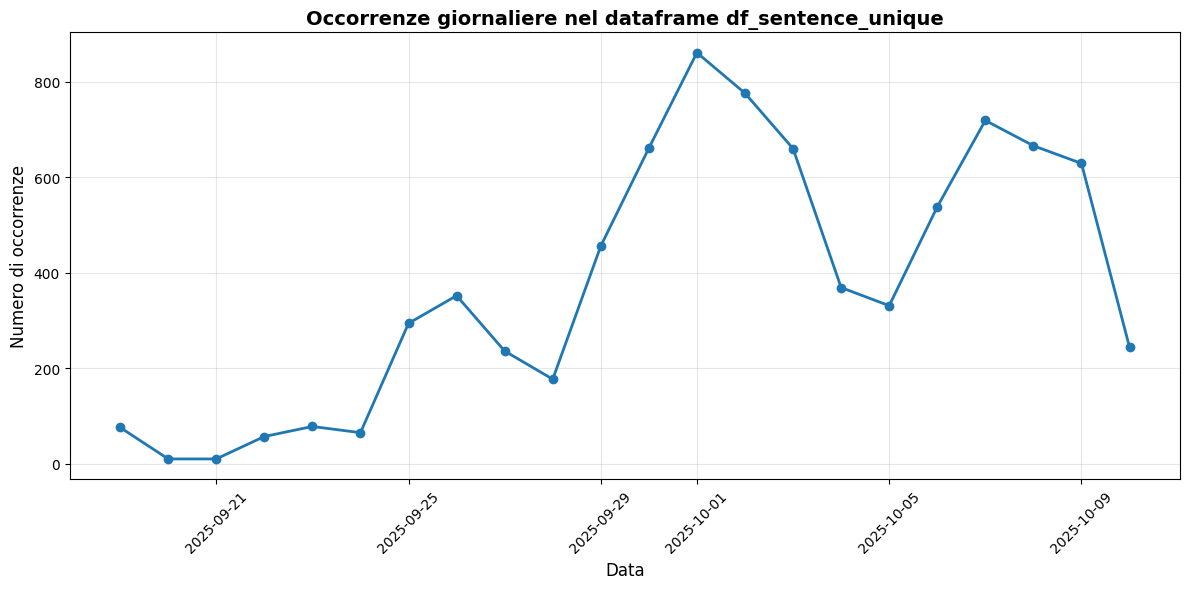

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime

# Assicurati che la colonna Date sia in formato datetime
df_sentence_unique['Date'] = pd.to_datetime(df_sentence_unique['Date'])

# Conta le occorrenze per data
daily_counts = df_sentence_unique['Date'].value_counts().sort_index()

# Crea il plot
plt.figure(figsize=(12, 6))
plt.plot(daily_counts.index, daily_counts.values, marker='o', linewidth=2, markersize=6)
plt.title('Occorrenze giornaliere nel dataframe df_sentence_unique', fontsize=14, fontweight='bold')
plt.xlabel('Data', fontsize=12)
plt.ylabel('Numero di occorrenze', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 1st Labeling Phase: Theme Match Labeling

This labeling step is to filter out the retrieved chunks that are not about the **main_theme**.

We only label the unique sentences, then the results are merged back to the original df.

In [13]:
from src.labeler.narrative_labeler import NarrativeLabeler
labeler = NarrativeLabeler(llm_model=llm_model)


In [14]:
df_sentence_unique_labeled = labeler.get_labels(
    main_theme="Government shutdown",
    texts=df_sentence_unique["Chunk Text"].tolist(),
    titles=df_sentence_unique["Headline"].tolist(),
    mode="theme_matching",
)

Querying OpenAI...:   0%|          | 0/8265 [00:00<?, ?it/s]

Querying OpenAI...: 100%|██████████| 8265/8265 [04:58<00:00, 27.67it/s]


In [15]:
df_sentence_unique_labeled.rename(columns={"label": "Theme Matching Label", "motivation": "Theme Matching Motivation"}, inplace=True)
df_sentence_unique_labeled_merged = merge(df_sentence_unique, df_sentence_unique_labeled, left_index=True, right_index=True)

# Select columns from df_sentence_unique_labeled_filtered
columns_to_merge = df_sentence_unique_labeled_merged[['Sentence ID', 'Theme Matching Label', 'Theme Matching Motivation']]

# Merge with df on Sentence ID
df_sentences_merged = df.merge(columns_to_merge, on='Sentence ID', how='left')
print(df_sentences_merged.shape)
df_sentences_related = df_sentences_merged[df_sentences_merged["Theme Matching Label"] != "unclear"]
print(df_sentences_related.shape)
df_sentences_related.to_csv("output_gov_shut/news_results_labeled_theme_matching_daily.csv", index=False)



(17485, 13)
(16358, 13)


# Creating the DF

In [16]:
df_sentences_related = pd.read_csv("output_gov_shut/news_results_labeled_theme_matching_daily.csv")

In [17]:
df_sentences_related

,Time Period,Date,Document ID,Sentence ID,Headline,Chunk Text,Motivation,Label,Entity,Country Code,Entity Type,Theme Matching Label,Theme Matching Motivation
0,Sep 2025,2025-09-19,034A2F2741069D470485B5BA1D14B1B5,034A2F2741069D470485B5BA1D14B1B5-6,Dow Jones & Nasdaq 100 Edged Higher Ahead of t...,The Trump-Xi call is scheduled for 9 am Easter...,The sentence discusses various factors influen...,Government shutdown creates market volatility ...,Xi Jinping,NaN,PEOP,related,The sentence mentions 'government shutdown ris...
1,Sep 2025,2025-09-19,034A2F2741069D470485B5BA1D14B1B5,034A2F2741069D470485B5BA1D14B1B5-6,Dow Jones & Nasdaq 100 Edged Higher Ahead of t...,The Trump-Xi call is scheduled for 9 am Easter...,The sentence discusses various factors influen...,Government shutdown creates market volatility ...,Donald Trump,NaN,PEOP,related,The sentence mentions 'government shutdown ris...
2,Sep 2025,2025-09-19,034A2F2741069D470485B5BA1D14B1B5,034A2F2741069D470485B5BA1D14B1B5-6,Dow Jones & Nasdaq 100 Edged Higher Ahead of t...,The Trump-Xi call is scheduled for 9 am Easter...,The sentence discusses various factors influen...,Government shutdown creates market volatility ...,NASDAQ 100 Index,United States,ORGA,related,The sentence mentions 'government shutdown ris...
3,Sep 2025,2025-09-19,034A2F2741069D470485B5BA1D14B1B5,034A2F2741069D470485B5BA1D14B1B5-6,Dow Jones & Nasdaq 100 Edged Higher Ahead of t...,The Trump-Xi call is scheduled for 9 am Easter...,The sentence discusses various factors influen...,Government shutdown creates market volatility ...,United States Federal Reserve,United States,ORGA,related,The sentence mentions 'government shutdown ris...
4,Sep 2025,2025-09-19,100CBEE70E4FC127CA9C5DBE7EB3261E,100CBEE70E4FC127CA9C5DBE7EB3261E-7,Wall St Closes Higher; Indexes Notch Weekly Gains,"Also on Friday, the Senate blocked a short-ter...",The sentence discusses the Senate blocking a f...,Shutdown creates uncertainty for government-de...,S&P 500,United States,ORGA,related,The sentence discusses the Senate blocking a s...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16353,Oct 2025,2025-10-10,FC345B21257AE1A9504951B1E18B37E9,FC345B21257AE1A9504951B1E18B37E9-4,"Wall Street closes lower, pausing record-setti...",The U.S. government shutdown entered its ninth...,The sentence discusses the impact of the gover...,Government data releases and reports are suspe...,The Federal Reserve Bank of New York,United States,ORGA,related,The sentence discusses the ongoing U.S. govern...
16354,Oct 2025,2025-10-10,FC345B21257AE1A9504951B1E18B37E9,FC345B21257AE1A9504951B1E18B37E9-4,"Wall Street closes lower, pausing record-setti...",The U.S. government shutdown entered its ninth...,The sentence discusses the impact of the gover...,Government data releases and reports are suspe...,New York Times Co.,United States,COMP,related,The sentence discusses the ongoing U.S. govern...
16355,Oct 2025,2025-10-10,FE07D980914FB4A4582816F456FF35CA,FE07D980914FB4A4582816F456FF35CA-6,"XRP, DOGE, SOL See Friday Pullback as $2.2B Fl...","Looking ahead, ETF flows would be the real tes...",The sentence discusses the uncertainty created...,Government shutdown creates market volatility ...,Government of the United States,United States,ORGA,related,The sentence explicitly mentions the U.S. gove...
16356,Oct 2025,2025-10-10,FF5C7C5CFAB00D566E0C09CCC19AA6F7,FF5C7C5CFAB00D566E0C09CCC19AA6F7-4,"NZ stocks retreat from record high, down 0.7%","""The US Government shutdown is starting to wei...",The sentence discusses the impact of the US Go...,Government shutdown creates market volatility ...,United States of America,United States,PLCE,related,The sentence explicitly mentions the US Govern...


In [19]:
top_x_people = 5
dict_people = {}

df_people = df_sentences_related[df_sentences_related["Entity Type"] == "PEOP"].copy()

# Keep track of top people for full range (count unique Sentence IDs per person)
entity_sentence_counts = df_people.groupby("Entity")["Sentence ID"].nunique().sort_values(ascending=False)
top_people_full_range = entity_sentence_counts.head(top_x_people).index.tolist()
print(top_people_full_range)

# Get top people per day (count unique Sentence IDs per person per day)
top_people_per_day = {}
for date in df_people["Date"].unique():
    df_day = df_people[df_people["Date"] == date]
    entity_counts = df_day.groupby("Entity")["Sentence ID"].nunique().sort_values(ascending=False)
    top_people_per_day[date] = entity_counts.head(top_x_people).index.tolist()


# Get all unique people from top_people_per_day only
all_top_people = set()
for people_list in top_people_per_day.values():
    all_top_people.update(people_list)

# Create dictionary with dataframes for each person in all_top_people
for person in all_top_people:
    df_person = df_sentences_related[df_sentences_related["Entity"] == person]
    # Keep only first occurrence of each unique Chunk Text
    df_person = df_person.drop_duplicates(subset="Chunk Text", keep="first")
    df_person = df_person.reset_index(drop=True)
    dict_people[person] = df_person

dict_people.keys()

['Donald Trump', 'Russell Vought', 'Sean Duffy', 'Chuck Schumer', 'Jerome Powell']


dict_keys(['Bernie Sanders', 'Xi Jinping', 'Joni Ernst', 'Janet Yellen', 'Brian Schatz', 'Mark M. Zandi', 'Mitch McConnell', 'Ami Bera', 'Chuck Schumer', 'Karoline Leavitt', 'John Kennedy', 'J. D. Vance', 'Francesco Pesole', 'Mike Johnson', 'Jamie Dimon', 'John Williams', 'Hakeem Jeffries', 'Elon Musk', 'Jennifer Garner', 'Russell Vought', 'Jerome Powell', 'Jim Cramer', 'Tim Kaine', 'Tina Smith', 'Barack Obama', 'Kevin Hassett', 'Michael Barr', 'Thomas I. Barkin', 'Scott Bessent', 'Sean Duffy', 'Donald Trump', 'Jim McGovern', 'Joe Biden'])

['Donald Trump',
 'Sean Duffy',
 'Russell Vought',
 'Karoline Leavitt',
 'J. D. Vance']

In [24]:
top_x_companies = 5
dict_companies = {}

exclude_companies = {'CNN', 'Bloomberg Inc.','CNBC LLC','New York Times Co.','CBS News Inc.','NBCUniversal Media LLC','American Broadcasting System Inc.'}

df_companies = df_sentences_related[df_sentences_related["Entity Type"] == "COMP"].copy()

# Keep track of top companies for full range (count unique Sentence IDs per company)
entity_sentence_counts = df_companies.groupby("Entity")["Sentence ID"].nunique().sort_values(ascending=False)
top_companies_full_range = [c for c in entity_sentence_counts.index if c not in exclude_companies][:top_x_companies]
print(top_companies_full_range)

# Get top companies per day (count unique Sentence IDs per company per day)
top_companies_per_day = {}
for date in df_companies["Date"].unique():
    df_day = df_companies[df_companies["Date"] == date]
    entity_counts = df_day.groupby("Entity")["Sentence ID"].nunique().sort_values(ascending=False)
    filtered_entities = [c for c in entity_counts.index if c not in exclude_companies][:top_x_companies]
    top_companies_per_day[date] = filtered_entities


# Get all unique companies from top_companies_per_day only
all_top_companies = set()
for company_list in top_companies_per_day.values():
    all_top_companies.update(company_list)

# Create dictionary with dataframes for each company in all_top_companies
for company in all_top_companies:
    df_company = df_sentences_related[df_sentences_related["Entity"] == company]
    # Keep only first occurrence of each unique Chunk Text
    df_company = df_company.drop_duplicates(subset="Chunk Text", keep="first")
    df_company = df_company.reset_index(drop=True)
    dict_companies[company] = df_company

dict_companies.keys()

['American Airlines Group Inc.', 'Delta Air Lines Inc.', 'National Air Traffic Controllers Association', 'Southwest Airlines Co.', 'NVIDIA Corp.']


dict_keys(['EY-Parthenon Co.', 'Bank of New York Mellon Corp.', 'PepsiCo Inc.', 'Paccar Inc.', 'Fox News Network LLC', 'Carson Group', 'Holland & Hart LLP', 'Armed Services Board of Contract Appeals', 'MarketWatch Inc.', 'Lockheed Martin Corp.', 'CarMax Inc.', 'Mercury Systems Inc.', 'Automatic Data Processing Inc.', 'Fannie Mae', 'Interactive Brokers Group Inc.', 'National Grocers Association', 'GM (General Motors Co.)', 'Lennar Corp.', 'Kalshi Inc.', 'TechCrunch Inc.', 'Yahoo Inc.', 'Levi Strauss & Co.', 'Costco Wholesale Corp.', 'JPMorgan Chase & Co.', 'S&P Global Inc.', 'BETA Technologies Inc.', 'Palantir Technologies Inc.', 'Carson Group Holdings LLC', 'Southwest Airlines Co.', 'Micron Technology Inc.', 'Cowen Inc.', 'Redfin Corp.', 'Delta Air Lines Inc.', 'The Associated Press Co.', 'The Washington Post', 'Oracle Corp.', 'GOBankingRates', 'Raymond James Financial Inc.', 'Tesla Inc.', 'Solana ETF', 'Goldman Sachs Group Inc.', 'Scholastic Corp.', 'CME Group Inc.', 'Freddie Mac', 'N

In [26]:
top_companies_full_range

['American Airlines Group Inc.',
 'National Air Traffic Controllers Association',
 'Southwest Airlines Co.',
 'Delta Air Lines Inc.',
 'Wells Fargo Investment Institute Inc.']

In [14]:
from src.labeler.screener_labeler import ScreenerLabelerFlex
from src.labeler.narrative_labeler import NarrativeSummarizerFlex

In [15]:
import importlib
import sys

# Remove the module from cache if it exists
if 'src.labeler.narrative_labeler' in sys.modules:
    del sys.modules['src.labeler.narrative_labeler']

# Force reimport
from src.labeler.narrative_labeler import NarrativeLabeler
importlib.reload(sys.modules['src.labeler.narrative_labeler'])

import importlib
from src.prompts import labeler
importlib.reload(labeler)
from src.prompts.labeler import get_narrative_system_prompt
from src.prompts import labeler


## 2nd Labeling Phase: Entity Relevance

This checks if the chunk is related to the entity or if the entity has been just side mentioned

In [28]:
dict_entities = dict_people | dict_companies

# Mantieni solo le chiavi presenti nelle liste top
top_keys = set(top_people_full_range) | set(top_companies_full_range)
dict_entities = {k: v for k, v in dict_entities.items() if k in top_keys}

In [30]:
labeler = NarrativeLabeler(llm_model=llm_model)



dict_entity_reference = {}


removed_count=0

for entity in dict_entities.keys():
    print(f"Processing {entity}, {len(dict_entities[entity])} sentences")
    df_temp = dict_entities[entity].copy()
    df_entity_reference = labeler.get_labels(
        main_theme="United States Government Shutdown",
        texts=df_temp["Chunk Text"].tolist(),
        titles=df_temp["Headline"].tolist(),
        mode="entity_reference",
        entity_track=entity
    )
    df_entity_reference.rename(columns={"label": "Entity Reference Label", "motivation": "Entity Reference Motivation"}, inplace=True)
    df_temp_merged = merge(df_temp, df_entity_reference, left_index=True, right_index=True)
    df_temp_merged = df_temp_merged[df_temp_merged['Entity Reference Label'].isin(['DIRECT', 'MENTION'])]
    df_temp_merged = df_temp_merged.reset_index(drop=True)
    print(f"Kept {len(df_temp_merged)} and removed {len(df_temp) - len(df_temp_merged)}")
    removed_count+=len(df_temp) - len(df_temp_merged)
    dict_entity_reference[entity] = df_temp_merged

print(f"Removed {removed_count} sentences")



import pickle

# Save the dictionary
with open('output_gov_shut/dict_entity_reference.pkl', 'wb') as f:
    pickle.dump(dict_entity_reference, f)

Processing Karoline Leavitt, 9 sentences


Querying OpenAI...:   0%|          | 0/9 [00:00<?, ?it/s]

Querying OpenAI...: 100%|██████████| 9/9 [00:01<00:00,  5.80it/s]


Kept 9 and removed 0
Processing Donald Trump, 198 sentences


Querying OpenAI...: 100%|██████████| 198/198 [00:14<00:00, 13.58it/s]


...

Kept 10 and removed 3
Processing American Airlines Group Inc., 17 sentences


Querying OpenAI...: 100%|██████████| 17/17 [00:03<00:00,  5.31it/s]


Kept 7 and removed 10
Processing Wells Fargo Investment Institute Inc., 11 sentences


Querying OpenAI...: 100%|██████████| 11/11 [00:02<00:00,  4.43it/s]

Kept 11 and removed 0
Removed 43 sentences


In [31]:
import pickle

with open('output_gov_shut/dict_entity_reference.pkl', 'rb') as f:
    dict_entity_reference = pickle.load(f)

In [32]:
import importlib
import sys

# Remove the module from cache if it exists
if 'src.labeler.narrative_labeler' in sys.modules:
    del sys.modules['src.labeler.narrative_labeler']

# Force reimport
from src.labeler.narrative_labeler import NarrativeLabeler, NarrativeSummarizerFlex
importlib.reload(sys.modules['src.labeler.narrative_labeler'])

import importlib
from src.prompts import labeler
importlib.reload(labeler)
from src.prompts.labeler import get_narrative_system_prompt
from src.prompts import labeler
from src.labeler.narrative_labeler import NarrativeLabeler, NarrativeSummarizerFlex


# Summarization

## First Summarization

For each **Entity** in the dataframe and for each available **Date** a the functions creates a **Daily Summary** with a list of **Daily Key Points** which aim to highlights the most important aspect of the **Daily Summary** in a sintetic/analytic way.

In [34]:
narrative_summarizer = NarrativeSummarizerFlex(llm_model="openai::gpt-4o-mini")

import json

dict_entity_summaries = {}

for entity in dict_entity_reference.keys():
    df_person = pd.DataFrame()
    print(f"Processing {entity}, {len(dict_entity_reference[entity])} sentences")
    date_list = dict_entity_reference[entity]["Date"].unique().tolist()
    for date in date_list:
        df_temp = dict_entity_reference[entity][dict_entity_reference[entity]["Date"] == date].copy()
        df_temp["Daily Summary"] = None
        df_temp["Daily Key Points"] = None
        daily_recap = narrative_summarizer.get_summaries(
            main_theme="United States Government Shutdown",
            df=df_temp,
            mode="entity_daily_summary_and_keypoints", 
            entity_track=entity,
        )
        summary = daily_recap["summary"].iloc[0]
        key_points = daily_recap["key_points"].iloc[0]
        # Serializza key_points come stringa JSON per evitare problemi di salvataggio
        key_points_serialized = json.dumps(key_points, ensure_ascii=False)
        df_temp["Daily Summary"] = summary
        df_temp["Daily Key Points"] = key_points_serialized
        df_person = pd.concat([df_person, df_temp])
    dict_entity_summaries[entity] = df_person


with open('output_gov_shut/dict_entity_summaries.pkl', 'wb') as f:
    pickle.dump(dict_entity_summaries, f)


Processing Karoline Leavitt, 9 sentences
DEBUG: SYSTEM PROMPT

Forget all previous prompts.
You are assisting a professional analyst in creating comprehensive sum
DEBUG: USER PROMPTS (Total: 1)
PROMPT 1:
----------------------------------------
{"Person": "Karoline Leavitt", "Chunk_1": "White House Press Secretary Karoline Leavitt on Monday suggested a shutdown would lead to significant impacts in government operations.\n\"It will only hurt the most vulnerable in our country: our seniors, our veterans, our military families,\" Leavitt said."}
----------------------------------------


Querying OpenAI...: 100%|██████████| 1/1 [00:02<00:00,  2.47s/it]

DEBUG: SYSTEM PROMPT

Forget all previous prompts.
You are assisting a professional analyst in creating comprehensive sum
DEBUG: USER PROMPTS (Total: 1)
PROMPT 1:
----------------------------------------
{"Person": "Karoline Leavitt", "Chunk_1": "White House press secretary Karoline Leavitt said Wednesday that she expected layoffs to begin this week.\nMany government agencies can't complete routine tasks\nAs in previous years, some agencies are almost completely shuttered, including the Education, Commerce, Labor and State departments. More than 90 percent of the National Labor Relations Board and the Equal Employment Opportunity Commission is being placed on furlough, as is more than 80 percent of NASA - representing 15,000 people - planning documents show."}
----------------------------------------



Querying OpenAI...: 100%|██████████| 1/1 [00:04<00:00,  4.74s/it]

DEBUG: SYSTEM PROMPT

Forget all previous prompts.
You are assisting a professional analyst in creating comprehensive sum
DEBUG: USER PROMPTS (Total: 1)
PROMPT 1:
----------------------------------------
{"Person": "Karoline Leavitt", "Chunk_1": "The Office of Management and Budget said late last month that agencies should consider layoffs for shutdown programs whose funding is not otherwise funded and is \"not consistent with the President's priorities,\" and White House press secretary Karoline Leavitt said this week that layoffs were \"imminent.\"", "Chunk_2": "According to the Congressional Budget Office (CBO), as many as 750,000 federal employees have the potential to be furloughed each day at a total daily cost of $400 million.\nLeavitt also said Monday, \"The Office of Management and Budget is continuing to work with agencies on who, unfortunately, is going to have to be laid off if this shutdown continues.\""}
----------------------------------------


...


Querying OpenAI...: 100%|██████████| 1/1 [00:03<00:00,  3.95s/it]

DEBUG: SYSTEM PROMPT

Forget all previous prompts.
You are assisting a professional analyst in creating comprehensive sum
DEBUG: USER PROMPTS (Total: 1)
PROMPT 1:
----------------------------------------
{"Company": "Wells Fargo Investment Institute Inc.", "Chunk_1": "\"The biggest impact on financial markets could be the economic reports that may not be released during a shutdown. This is particularly problematic as labor markets may be softening and the Federal Reserve (Fed) will be looking for data to support additional rate cuts at upcoming meetings. The September jobs report is set to be released on Friday and could be one of the first major economic releases impacted by a shutdown,\" Analysts at Wells Fargo Investment Institute said. \"Should a government shutdown drag on, other major data releases such as weekly jobless claims, Consumer Price Index (CPI), retail sales, and Producer Price Index (PPI) could be impacted.\"", "Chunk_2": "The shutdown will last until at least Friday 


Querying OpenAI...: 100%|██████████| 1/1 [00:04<00:00,  4.66s/it]

DEBUG: SYSTEM PROMPT

Forget all previous prompts.
You are assisting a professional analyst in creating comprehensive sum
DEBUG: USER PROMPTS (Total: 1)
PROMPT 1:
----------------------------------------
{"Company": "Wells Fargo Investment Institute Inc.", "Chunk_1": "Separately, Wells Fargo Investment Institute said the government shutdown and data delays are likely to serve as temporary market distractions.\n\"These headlines may incite Fed policy jitters and spark market volatility for a short time,\" the firm wrote. \"However, we remain focused on more durable investment trends that we believe are laying the groundwork for a positive market environment through 2026.\"", "Chunk_2": "Separately, Wells Fargo Investment Institute said the government shutdown and data delays are likely to serve as temporary market distractions.\n\"These headlines may incite (Federal Reserve) policy jitters and spark market volatility for a short time,\" the firm wrote. \"However, we remain focused on mo


Querying OpenAI...: 100%|██████████| 1/1 [00:03<00:00,  3.27s/it]


In [35]:
import pickle

with open('output_gov_shut/dict_entity_reference.pkl', 'rb') as f:
    dict_entity_reference = pickle.load(f)


Create unique dataframe with Entities - Summaries

In [36]:
all_dataframes = list(dict_entity_summaries.values())
df_entity_summaries = pd.concat(all_dataframes, ignore_index=True)
df_final_entity_summaries = df_entity_summaries.drop_duplicates(subset=['Entity', 'Date'], keep='first')
df_final_entity_summaries.to_csv("output_gov_shut/df_final_entity_summaries.csv", index=False)

In [38]:
df_final_entity_summaries = pd.read_csv("output_gov_shut/df_final_entity_summaries.csv")
df_final_entity_summaries


,Time Period,Date,Document ID,Sentence ID,Headline,Chunk Text,Motivation,Label,Entity,Country Code,Entity Type,Theme Matching Label,Theme Matching Motivation,Entity Reference Motivation,Entity Reference Label,Daily Summary,Daily Key Points
0,Sep 2025,2025-09-23,E13B12A916D201FB1B362C948143194C,E13B12A916D201FB1B362C948143194C-8,"As shutdown looms, federal agencies have no pu...",White House Press Secretary Karoline Leavitt o...,The sentence discusses the potential significa...,Government shutdown impacts federal contractor...,Karoline Leavitt,NaN,PEOP,related,The sentence discusses the potential impacts o...,Karoline Leavitt directly quotes her statement...,DIRECT,"Karoline Leavitt, the White House Press Secret...","[""Suggested a shutdown would lead to significa..."
1,Oct 2025,2025-10-02,4162B7F4BF6861E6504B45D7C82DB5F2,4162B7F4BF6861E6504B45D7C82DB5F2-11,What this government shutdown could cost,White House press secretary Karoline Leavitt s...,The sentence discusses the impact of governmen...,Federal employee furloughs reduce government a...,Karoline Leavitt,NaN,PEOP,related,The sentence discusses the impact of a governm...,Karoline Leavitt directly states her expectati...,DIRECT,"Karoline Leavitt, the White House press secret...","[""Expected layoffs to begin this week"", ""Highl..."
2,Oct 2025,2025-10-06,8FFE6283D601870E9A73AF0F8C352F8C,8FFE6283D601870E9A73AF0F8C352F8C-3,AP Reader Question: Is It Legal to Fire Furlou...,The Office of Management and Budget said late ...,The sentence discusses potential layoffs in ag...,Federal employee furloughs reduce government a...,Karoline Leavitt,NaN,PEOP,related,The sentence discusses the potential for layof...,Karoline Leavitt directly states that layoffs ...,DIRECT,Karoline Leavitt has positioned herself as a k...,"[""Stated that layoffs were \""imminent\"" due to..."
3,Oct 2025,2025-10-07,50FCE94CCD9E0144BCD0F698D4DF131B,50FCE94CCD9E0144BCD0F698D4DF131B-12,What Happens to Federal Workers During a Gover...,Can furloughed workers be fired?\nThe Trump Ad...,The sentence discusses the potential for layof...,Federal employee furloughs reduce government a...,Karoline Leavitt,NaN,PEOP,related,The sentence discusses the implications of a g...,Karoline Leavitt is directly quoted regarding ...,DIRECT,Karoline Leavitt is positioned at the forefron...,"[""Stated that layoffs of furloughed workers ar..."
4,Oct 2025,2025-10-08,8A3A56FDC3AB603078DDD666DC849A4B,8A3A56FDC3AB603078DDD666DC849A4B-5,Trump would wade into uncharted legal waters w...,Trump took office pledging to remake and sharp...,The sentence discusses the potential impact of...,Federal employee furloughs reduce government a...,Karoline Leavitt,NaN,PEOP,related,The sentence discusses the implications of a g...,Karoline Leavitt is mentioned as the White Hou...,MENTION,"Karoline Leavitt, as White House Press Secreta...","[""Clarified that President Trump's remarks abo..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,Sep 2025,2025-09-26,803EA1565FD83C6FAB081A8E4BF26432,803EA1565FD83C6FAB081A8E4BF26432-4,"S&P 500, Nasdaq set to end three-week gaining ...",Investors are also growing increasingly concer...,The sentence discusses how a potential governm...,Government data releases and reports are suspe...,Wells Fargo Investment Institute Inc.,United States,COMP,related,The sentence explicitly discusses concerns abo...,Wells Fargo Investment Institute Inc. is direc...,DIRECT,Wells Fargo Investment Institute Inc. is activ...,"[""Stated that disruption to data releases duri..."
57,Sep 2025,2025-09-29,EDEEA15C5F3AB909690D13C88536F92E,EDEEA15C5F3AB909690D13C88536F92E-8,Labor Dept. to delay economic data if governme...,"""We believe that a shutdown will have only a s...",The sentence discusses the potential for finan...,Government shutdown creates market volatility ...,Wells Fargo Investment Institute Inc.,United States,COMP,related,The sentence discusses the potential economic ...,Wells Fargo Investment Institute In

In [87]:
import importlib
import sys

# Remove the module from cache if it exists
if 'src.labeler.narrative_labeler' in sys.modules:
    del sys.modules['src.labeler.narrative_labeler']

# Force reimport
from src.labeler.narrative_labeler import NarrativeLabeler, NarrativeSummarizerFlex
importlib.reload(sys.modules['src.labeler.narrative_labeler'])

import importlib
from src.prompts import labeler
importlib.reload(labeler)
from src.prompts.labeler import get_narrative_system_prompt
from src.prompts import labeler
from src.labeler.narrative_labeler import NarrativeLabeler, NarrativeSummarizerFlex


In [44]:
df_final_entity_summaries.columns

Index(['Time Period', 'Date', 'Document ID', 'Sentence ID', 'Headline',
       'Chunk Text', 'Motivation', 'Label', 'Entity', 'Country Code',
       'Entity Type', 'Theme Matching Label', 'Theme Matching Motivation',
       'Entity Reference Motivation', 'Entity Reference Label',
       'Daily Summary', 'Daily Key Points'],
      dtype='object')

In [88]:
# Constants
MAIN_THEME = "Government shutdown"
OUTPUT_PATH = "output_gov_shut/entity_summaries_enhanced.csv"
LLM_MODEL = "openai::gpt-4o"

narrative_summarizer = NarrativeSummarizerFlex(llm_model=LLM_MODEL)

# Prepare input dataframe
df_input = df_final_entity_summaries.copy()
df_input["Novel Daily Summary"] = None
df_input["Highlights"] = None
df_input["entity_previous_narrative"] = None
df_input["previous_summary"] = None
df_input["today_summary"] = None
df_input["relevance"] = None
df_input = df_input.sort_values(['Entity', 'Date'])

# Process each entity
for entity_name in df_input['Entity'].unique():
    entity_df = df_input[df_input['Entity'] == entity_name].sort_values('Date')
    dates = sorted(entity_df["Date"].unique())
    
    daily_outputs_by_iteration = {}
    cumulative_historical_narrative = None
    
    for iteration, current_date in enumerate(dates):
        df_temp = entity_df[entity_df["Date"] == current_date]
        current_date_label = f"Date {str(current_date)}:"
        
        print(f"Processing: {entity_name}, Date: {current_date}, Iteration: {iteration}")
        print(f"Summary: {df_temp['Daily Summary'].iloc[0]}")
        print(f"Key points: {df_temp['Daily Key Points'].iloc[0]}\n")
        
        # Prepare narrative context for LLM
        if iteration == 0:
            narrative_context_for_llm = {entity_name: "There is no previous data to refer to, use the one of today"}
        else:
            narrative_context_for_llm = {f"{entity_name}_consolidated": cumulative_historical_narrative}
        
        # Temporal analysis: identify what's NEW today
        novel_daily_output = narrative_summarizer.get_summaries(
            main_theme=MAIN_THEME,
            df=df_temp,
            mode="temporal_company_narrative_from_summaries",
            entity_track=entity_name,
            previous_narrative=narrative_context_for_llm
        )
        
        # Extract results
        current_iteration_summary = novel_daily_output['summary'].iloc[0]
        current_iteration_key_points = novel_daily_output['key_points'].iloc[0]
        
        if not isinstance(current_iteration_key_points, list):
            current_iteration_key_points = [str(current_iteration_key_points)] if current_iteration_key_points else []
        
        # Get row index for this entity-date combination
        row_idx = df_input[(df_input["Entity"] == entity_name) & (df_input["Date"] == current_date)].index[0]
        
        # Update dataframe with temporal analysis results
        df_input.at[row_idx, "Novel Daily Summary"] = current_iteration_summary
        df_input.at[row_idx, "Highlights"] = current_iteration_key_points
        df_input.at[row_idx, "entity_previous_narrative"] = str(narrative_context_for_llm)
        
        # Store current iteration's output for consolidation
        key_points_joined = "\n".join(current_iteration_key_points) if current_iteration_key_points else ""
        
        if iteration == 0:
            # First iteration: initialize cumulative narrative
            daily_outputs_by_iteration[0] = f"{current_date_label}\n{current_iteration_summary}\n{key_points_joined}"
            cumulative_historical_narrative = daily_outputs_by_iteration[0]
            df_input.at[row_idx, "previous_summary"] = "N/A"
            df_input.at[row_idx, "today_summary"] = "N/A"
            df_input.at[row_idx, "relevance"] = "N/A"
        else:
            # Subsequent iterations: consolidate and update
            daily_outputs_by_iteration[iteration] = f"{current_iteration_summary}\n{key_points_joined}"
            
            print(f"Consolidation for iteration {iteration}")
            
            # Determine base and new summaries for consolidation
            base_narrative_for_merge = daily_outputs_by_iteration[0] if iteration == 1 else cumulative_historical_narrative
            new_summary_to_merge = daily_outputs_by_iteration[iteration]
            
            # Extract only NEW information from current iteration
            extracted_novel_info = narrative_summarizer.get_summaries(
                main_theme=MAIN_THEME,
                mode="company_narrative_consolidation",
                previous_summary=base_narrative_for_merge,
                today_summary=new_summary_to_merge,
                entity_track=entity_name,
            )
            
            # Update cumulative narrative with extracted new information
            if extracted_novel_info and extracted_novel_info.strip():
                cumulative_historical_narrative = f"{base_narrative_for_merge}\n{current_date_label}\n{extracted_novel_info}"
                print(f"✅ Consolidation extracted novel info for {current_date}")
            else:
                # Add explicit note that no relevant information was found
                no_info_message = f"No new relevant information for {MAIN_THEME}."
                cumulative_historical_narrative = f"{base_narrative_for_merge}\n{current_date_label}\n{no_info_message}"
                df_input.at[row_idx, "relevance"] = '{"consolidation": False}'
                print(f"⚠️  No relevant info found for {entity_name} on {current_date}")
                print(f"   No relevant summary: {current_iteration_summary[:150]}...")
                print(f"   No relevant key points: {current_iteration_key_points}")
                print(f"   Added note: '{no_info_message}'")
                print(f"   Relevance: {{'consolidation': false}}\n")
            
            # Update tracking columns for debugging
            df_input.at[row_idx, "previous_summary"] = base_narrative_for_merge
            df_input.at[row_idx, "today_summary"] = new_summary_to_merge

# Save results
df_entities_temporal_evolution = df_input.sort_values(['Entity', 'Date']).reset_index(drop=True)
df_entities_temporal_evolution.to_csv(OUTPUT_PATH, index=False)

Processing: American Airlines Group Inc., Date: 2025-09-30, Iteration: 0
Summary: American Airlines Group Inc. is positioned within the narrative of the United States Government Shutdown through its association with Airlines for America, which has issued warnings about the potential impacts of funding lapses. The group highlighted that a shutdown could lead to reduced efficiency in the airline system, longer wait times at airports, and delayed flights due to the furloughing of tens of thousands of federal workers. These statements underscore the airline's concern for operational efficiency and traveler experience amid the threat of a government shutdown.
Key points: ["Warned that if funding lapses, \"the system may need to slow down, reducing efficiency\" and impacting travelers.", "Highlighted that furloughing tens of thousands of federal workers would mean longer wait times at airports and delayed flights."]



Querying OpenAI...:   0%|          | 0/1 [00:00<?, ?it/s]

Querying OpenAI...: 100%|██████████| 1/1 [00:02<00:00,  2.92s/it]


Processing: American Airlines Group Inc., Date: 2025-10-01, Iteration: 1
Summary: American Airlines Group Inc. is positioned to face significant challenges due to the impending United States government shutdown. The airline, as part of the Airlines for America coalition, has raised concerns about potential disruptions in the aviation industry, particularly regarding staffing shortages at key federal agencies such as the Federal Aviation Administration (FAA), Customs and Border Protection, and the Transportation Security Administration. These shortages could lead to reduced efficiency and slower operations, impacting flight schedules and overall air travel experience.
Key points: ["Warned that possible staffing shortages at the Federal Aviation Administration, Customs and Border Protection, and the Transportation Security Administration may force the system to slow down, reducing efficiency.", "Highlighted that a partial federal government shutdown could strain American aviation and slo

Querying OpenAI...: 100%|██████████| 1/1 [00:02<00:00,  2.77s/it]


...

✅ Consolidation extracted novel info for 2025-10-02
Processing: Wells Fargo Investment Institute Inc., Date: 2025-10-06, Iteration: 4
Summary: Wells Fargo Investment Institute Inc. views the United States Government Shutdown as a potential short-term distraction for the markets, suggesting that it may lead to temporary volatility and concerns regarding Federal Reserve policy. Despite this, the firm emphasizes its commitment to long-term investment trends that are expected to foster a positive market environment through 2026.
Key points: ["Stated that the government shutdown and data delays are likely to serve as temporary market distractions.", "Warned that these headlines may incite Federal Reserve policy jitters and spark market volatility for a short time.", "Expressed a focus on durable investment trends that are believed to lay the groundwork for a positive market environment through 2026."]



Querying OpenAI...: 100%|██████████| 1/1 [00:02<00:00,  2.40s/it]


Consolidation for iteration 4


Querying OpenAI...: 100%|██████████| 1/1 [00:01<00:00,  1.27s/it]

✅ Consolidation extracted novel info for 2025-10-06


In [89]:
df_entities_temporal_evolution = pd.read_csv("output_gov_shut/entity_summaries_enhanced.csv")


In [90]:
df_entities_temporal_evolution["relevance"].value_counts()

relevance
{"consolidation": False}    4
Name: count, dtype: int64

## Generate Final Narrative for each of the Entities

In [91]:
narrative_summarizer = NarrativeSummarizerFlex(llm_model="openai::gpt-4o")


# Get final recap
entities_final_summary = narrative_summarizer.get_summaries(
    main_theme="Government shutdown",
    df=df_entities_temporal_evolution,
    mode="final_summary_from_daily_summaries",
)

entities_final_summary.rename(columns={"summary": "Final Summary"}, inplace=True)
df_entities_temporal_evolution_with_final_summary = df_entities_temporal_evolution.merge(entities_final_summary[["Entity","Final Summary"]], on='Entity', how='left')
df_entities_temporal_evolution_with_final_summary.to_csv("output_gov_shut/df_entities_temporal_evolution_with_final_summary.csv", index=False)

Querying OpenAI...:   0%|          | 0/10 [00:00<?, ?it/s]

Querying OpenAI...: 100%|██████████| 10/10 [00:09<00:00,  1.10it/s]


In [92]:
df_entities_temporal_evolution_with_final_summary = pd.read_csv("output_gov_shut/df_entities_temporal_evolution_with_final_summary.csv")

Add news coverage data to the dataframe starting cleaned dataframe

In [93]:
df_entities_temporal_evolution_with_final_summary

,Time Period,Date,Document ID,Sentence ID,Headline,Chunk Text,Motivation,Label,Entity,Country Code,...,Entity Reference Label,Daily Summary,Daily Key Points,Novel Daily Summary,Highlights,entity_previous_narrative,previous_summary,today_summary,relevance,Final Summary
0,Sep 2025,2025-09-30,0F2439BBAAACFB853B2AEE66CEB03B6A,0F2439BBAAACFB853B2AEE66CEB03B6A-7,FAA would furlough about a quarter of its staf...,"Airline trade group Airlines for America, whic...",The sentence discusses the potential impact of...,Airlines may experience operational challenges...,American Airlines Group Inc.,United States,...,MENTION,American Airlines Group Inc. is positioned wit...,"[""Warned that if funding lapses, \""the system ...",American Airlines Group Inc. is involved in th...,"['Warned that if funding lapses, ""the system m...",{'American Airlines Group Inc.': 'There is no ...,NaN,NaN,NaN,Throughout the period leading up to the potent...
1,Oct 2025,2025-10-01,106CEB87850B49B99E7E47EF682975E5,106CEB87850B49B99E7E47EF682975E5-4,"FAA Faces Furlough Of 11,000 Employees, Airlin...",Impact On Aviation Industry\nThe looming gover...,The sentence discusses the potential repercuss...,Airlines may experience operational challenges...,American Airlines Group Inc.,United States,...,MENTION,American Airlines Group Inc. is positioned to ...,"[""Warned that possible staffing shortages at t...",Today's information highlights specific concer...,['Warned that possible staffing shortages at t...,{'American Airlines Group Inc._consolidated': ...,Date 2025-09-30:\nAmerican Airlines Group Inc....,Today's information highlights specific concer...,NaN,Throughout the period leading up to the potent...
2,Oct 2025,2025-10-06,D723B9BB6BAFB84DE2583669D24976BC,D723B9BB6BAFB84DE2583669D24976BC-8,Staffing issues cause delays at US airports as...,"Airline trade group Airlines for America, whic...",The sentence discusses the impact of a funding...,Airlines may experience operational challenges...,American Airlines Group Inc.,United States,...,MENTION,American Airlines Group Inc. is positioned wit...,"[""Warned that a funding lapse may lead to redu...",Today's information introduces new details abo...,['Highlighted the ongoing shortage of air traf...,{'American Airlines Group Inc._consolidated': ...,Date 2025-09-30:\nAmerican Airlines Group Inc....,Today's information introduces new details abo...,NaN,Throughout the period leading up to the potent...
3,Sep 2025,2025-09-30,0F2439BBAAACFB853B2AEE66CEB03B6A,0F2439BBAAACFB853B2AEE66CEB03B6A-7,FAA would furlough about a quarter of its staf...,"Airline trade group Airlines for America, whic...",The sentence discusses the potential impact of...,Airlines may experience operational challenges...,Delta Air Lines Inc.,United States,...,MENTION,Delta Air Lines Inc. is positioned within the ...,"[""Warned that if funding lapses, \""the system ...",Delta Air Lines Inc. is involved in the discus...,"['Delta Air Lines, through Airlines for Americ...",{'Delta Air Lines Inc.': 'There is no previous...,NaN,NaN,NaN,Delta Air Lines Inc. has been actively involve...
4,Oct 2025,2025-10-01,106CEB87850B49B99E7E47EF682975E5,106CEB87850B49B99E7E47EF682975E5-4,"FAA Faces Furlough Of 11,000 Employees, Airlin...",Impact On Aviation Industry\nThe looming gover...,The sentence discusses the potential repercuss...,Airlines may experience operational challenges...,Delta Air Lines Inc.,United States,...,MENTION,Delta Air Lines Inc. is positioned at the fore...,"[""Issued a warning that the government shutdow...","Delta Air Lines Inc., through its association ...",['Issued a warning that the government shutdow...,{'Delta Air Lines Inc._consolidated': 'Date 20...,Date 2025-09-30:\nDelta Air Lines Inc. is invo...,"Delta Air Lines Inc., through its association ...",NaN,Delta Air Lines Inc. has been actively involve...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,Sep 2025,2025-09-26,803EA1565FD83C6FAB081A8E4BF26432,803EA1

In [94]:
# Filter the first dataframe to keep only entities present in the second dataframe
entities_in_second_df = df_entities_temporal_evolution_with_final_summary['Entity'].unique()
df_sentences_related = df_sentences_related[df_sentences_related['Entity'].isin(entities_in_second_df)]

# Merge the two dataframes based on Date and Entity
df_final_news_coverage = df_sentences_related.merge(
    df_entities_temporal_evolution_with_final_summary[['Date', 'Entity', 
                                                         'Entity Reference Motivation', 
                                                         'Entity Reference Label',
                                                         'Daily Summary', 
                                                         'Daily Key Points', 
                                                         'Novel Daily Summary',
                                                         'Highlights', 
                                                         'Final Summary',
                                                         'relevance']],
    on=['Date', 'Entity'],
    how='left'
)

df_final_news_coverage = df_final_news_coverage[df_final_news_coverage['Entity Reference Motivation'].notna()]
df_final_news_coverage.reset_index(drop=True, inplace=True)
df_final_news_coverage.to_csv("output_gov_shut/df_final_news_coverage.csv", index=False)
df_final_news_coverage = pd.read_csv("output_gov_shut/df_final_news_coverage.csv")

In [95]:
df_final_news_coverage = pd.read_csv("output_gov_shut/df_final_news_coverage.csv")

# CREATE VISUALIZATIONS

In [96]:
import importlib
import sys

# Forza il reload del modulo 'src.report.plots'
if 'src.report.plots' in sys.modules:
    importlib.reload(sys.modules['src.report.plots'])

# Importa nuovamente la funzione aggiornata
from src.report.plots import create_entity_temporal_coverage_chart



In [97]:
# Import the function
from src.report.plots import create_entity_temporal_coverage_chart

# Create the chart
fig = create_entity_temporal_coverage_chart(df_final_news_coverage)

# Show it
fig.show()

# Opzionalmente salvarlo
fig.write_html("entity_coverage_timeline.html")

## Generate Final Summary

The final summary is the summary generetad by the final summaries of each entity

In [98]:
import importlib
import sys

# Remove the module from cache if it exists
if 'src.labeler.narrative_labeler' in sys.modules:
    del sys.modules['src.labeler.narrative_labeler']

# Force reimport
from src.labeler.narrative_labeler import NarrativeLabeler, NarrativeSummarizerFlex
importlib.reload(sys.modules['src.labeler.narrative_labeler'])

import importlib
from src.prompts import labeler
importlib.reload(labeler)
from src.prompts.labeler import get_narrative_system_prompt
from src.prompts import labeler
from src.labeler.narrative_labeler import NarrativeLabeler, NarrativeSummarizerFlex

In [99]:
narrative_summarizer = NarrativeSummarizerFlex(llm_model="openai::gpt-4o")

final_summary = narrative_summarizer.get_summaries(
    main_theme="Most important event about the government shutdown",
    df=df_entities_temporal_evolution_with_final_summary,
    mode="final_summary_general_report",
)

# final_summary è una stringa, salvala
with open("output_gov_shut/final_summary.txt", "w", encoding="utf-8") as f:
    f.write(final_summary)

Querying OpenAI...: 100%|██████████| 1/1 [00:13<00:00, 13.46s/it]


In [100]:
df_final_news_coverage.columns

Index(['Time Period', 'Date', 'Document ID', 'Sentence ID', 'Headline',
       'Chunk Text', 'Motivation', 'Label', 'Entity', 'Country Code',
       'Entity Type', 'Theme Matching Label', 'Theme Matching Motivation',
       'Entity Reference Motivation', 'Entity Reference Label',
       'Daily Summary', 'Daily Key Points', 'Novel Daily Summary',
       'Highlights', 'Final Summary', 'relevance'],
      dtype='object')

In [101]:
df_final_news_coverage.head()

,Time Period,Date,Document ID,Sentence ID,Headline,Chunk Text,Motivation,Label,Entity,Country Code,...,Theme Matching Label,Theme Matching Motivation,Entity Reference Motivation,Entity Reference Label,Daily Summary,Daily Key Points,Novel Daily Summary,Highlights,Final Summary,relevance
0,Sep 2025,2025-09-19,034A2F2741069D470485B5BA1D14B1B5,034A2F2741069D470485B5BA1D14B1B5-6,Dow Jones & Nasdaq 100 Edged Higher Ahead of t...,The Trump-Xi call is scheduled for 9 am Easter...,The sentence discusses various factors influen...,Government shutdown creates market volatility ...,Donald Trump,NaN,...,related,The sentence mentions 'government shutdown ris...,Donald Trump is mentioned in the context of a ...,MENTION,The narrative surrounding the United States Go...,"[""Stated that if Senate Democrats pursue a Sch...",Today's information introduces concerns that a...,['Concerns that a government shutdown could em...,The ongoing U.S. government shutdown has been ...,NaN
1,Sep 2025,2025-09-19,33B624AFD60B5B71370047FDF17374ED,33B624AFD60B5B71370047FDF17374ED-52,Even Ted Cruz Recognizes Jimmy Kimmel's Suspen...,A shutdown would give the Trump administration...,The sentence discusses the potential consequen...,Federal employee furloughs reduce government a...,Donald Trump,NaN,...,related,The sentence discusses the implications of a g...,Donald Trump is mentioned in the context of a ...,MENTION,The narrative surrounding the United States Go...,"[""Stated that if Senate Democrats pursue a Sch...",Today's information introduces concerns that a...,['Concerns that a government shutdown could em...,The ongoing U.S. government shutdown has been ...,NaN
2,Sep 2025,2025-09-19,35C62007D88782D5E8809A238FDFF44F,35C62007D88782D5E8809A238FDFF44F-7,House Kicks Off Chaotic Battle After Passing S...,A shutdown would give the Trump administration...,The sentence discusses the potential consequen...,Federal employee furloughs reduce government a...,Donald Trump,NaN,...,related,The sentence discusses the implications of a g...,Donald Trump is mentioned in the context of a ...,MENTION,The narrative surrounding the United States Go...,"[""Stated that if Senate Democrats pursue a Sch...",Today's information introduces concerns that a...,['Concerns that a government shutdown could em...,The ongoing U.S. government shutdown has been ...,NaN
3,Sep 2025,2025-09-19,425678FD0C20BEF2F85395D86DA31DD6,425678FD0C20BEF2F85395D86DA31DD6-10,Government shutdown looms after Senate rejects...,"""If Senate Democrats insist on a Schumer Shutd...",The sentence discusses concerns among Democrat...,Federal employee furloughs reduce government a...,Donald Trump,NaN,...,related,The sentence discusses the potential consequen...,Donald Trump is mentioned in the context of a ...,MENTION,The narrative surrounding the United States Go...,"[""Stated that if Senate Democrats pursue a Sch...",Today's information introduces concerns that a...,['Concerns that a government shutdown could em...,The ongoing U.S. government shutdown has been ...,NaN
4,Sep 2025,2025-09-19,4EE14B9F3BEEAF4FCA3D93AB478FF354,4EE14B9F3BEEAF4FCA3D93AB478FF354-31,"Judge Shreds Trump's NYT Lawsuit for Lacking ""...",A shutdown would give the Trump administration...,The sentence discusses the potential consequen...,Federal employee furloughs reduce government a...,Donald Trump,NaN,...,related,The sentence discusses the implications of a g...,Donald Trump is mentioned in the context of a ...,MENTION,The narrative surrounding the United States Go...,"[""Stated that if Senate Democrats pursue a Sch...",Today's information introduces concerns that a...,['Concerns that a government shutdown could em...,The ongoing U.S. government shutdown has been ...,NaN


In [102]:
# Calculate total unique documents in the dataset (across all dates)
unique_documents_count = df_final_news_coverage['Document ID'].nunique()

# Extract all unique entities with their types and country codes
all_entities = df_final_news_coverage[['Entity', 'Entity Type', 'Country Code']].drop_duplicates()

# Get unique dates
unique_dates = sorted(df_final_news_coverage['Date'].unique())

# Calculate statistics for each entity
entity_data = []

# First, iterate by entity
for _, entity_row in all_entities.iterrows():
    entity = entity_row['Entity']
    entity_type = entity_row['Entity Type']
    country_code = entity_row['Country Code'] if pd.notna(entity_row['Country Code']) else None
    
    # Get all rows for this entity across ALL dates (for Overall statistics)
    entity_all_rows = df_final_news_coverage[df_final_news_coverage['Entity'] == entity]
    overall_total_sentences = len(entity_all_rows)
    overall_unique_documents = entity_all_rows['Document ID'].nunique()
    overall_percentage_documents = round((overall_unique_documents / unique_documents_count * 100) if unique_documents_count > 0 else 0, 2)
    
    # Now iterate through each date for this entity
    for date in unique_dates:
        # Filter data for this specific date (ALL entities)
        date_data = df_final_news_coverage[df_final_news_coverage['Date'] == date]
        total_unique_docs_date = date_data['Document ID'].nunique()
        
        # Get rows for this entity on this specific date
        entity_date_rows = date_data[date_data['Entity'] == entity]
        total_sentences = len(entity_date_rows)
        unique_documents = entity_date_rows['Document ID'].nunique()
        percentage_documents = round((unique_documents / total_unique_docs_date * 100) if total_unique_docs_date > 0 else 0, 2)
        
        entity_data.append({
            'Date': date,
            'Entity': entity,
            'Entity_Type': entity_type,
            'Country_Code': country_code,
            'Total_Sentences': total_sentences,
            'Unique_Documents': unique_documents,
            'Total_Unique_Documents': total_unique_docs_date,
            'Percentage_Documents': percentage_documents,
            'Overall_Total_Sentences': overall_total_sentences,
            'Overall_Unique_Documents': overall_unique_documents,
            'Overall_Percentage_Documents': overall_percentage_documents
        })

# Create final dataframe
entity_stats = pd.DataFrame(entity_data)
entity_stats = entity_stats.sort_values(['Date', 'Unique_Documents'], ascending=[True, False])
entity_stats.reset_index(drop=True, inplace=True)
# Display the results

entity_stats.to_csv("output_gov_shut/entity_stats.csv", index=False)
entity_stats.head(20)

,Date,Entity,Entity_Type,Country_Code,Total_Sentences,Unique_Documents,Total_Unique_Documents,Percentage_Documents,Overall_Total_Sentences,Overall_Unique_Documents,Overall_Percentage_Documents
0,2025-09-19,Donald Trump,PEOP,None,18,18,18,100.0,1087,982,82.73
1,2025-09-19,Karoline Leavitt,PEOP,None,0,0,18,0.0,30,29,2.44
2,2025-09-19,Russell Vought,PEOP,None,0,0,18,0.0,112,109,9.18
3,2025-09-19,Wells Fargo Investment Institute Inc.,COMP,United States,0,0,18,0.0,19,19,1.60
4,2025-09-19,Sean Duffy,PEOP,None,0,0,18,0.0,71,66,5.56
5,2025-09-19,Delta Air Lines Inc.,COMP,United States,0,0,18,0.0,17,17,1.43
6,2025-09-19,American Airlines Group Inc.,COMP,United States,0,0,18,0.0,27,25,2.11
7,2025-09-19,J. D. Vance,PEOP,None,0,0,18,0.0,30,28,2.36
8,2025-09-19,National Air Traffic Controllers Association,COMP,United States,0,0,18,0.0,27,25,2.11
9,2025-09-19,Southwest Airlines Co.,COMP,United States,0,0,18,0.0,13,13,1.10


In [139]:
entity_stats.columns

Index(['Date', 'Entity', 'Entity_Type', 'Country_Code', 'Total_Sentences',
       'Unique_Documents', 'Total_Unique_Documents', 'Percentage_Documents',
       'Overall_Total_Sentences', 'Overall_Unique_Documents',
       'Overall_Percentage_Documents'],
      dtype='object')

In [103]:
df_final_news_coverage.columns

Index(['Time Period', 'Date', 'Document ID', 'Sentence ID', 'Headline',
       'Chunk Text', 'Motivation', 'Label', 'Entity', 'Country Code',
       'Entity Type', 'Theme Matching Label', 'Theme Matching Motivation',
       'Entity Reference Motivation', 'Entity Reference Label',
       'Daily Summary', 'Daily Key Points', 'Novel Daily Summary',
       'Highlights', 'Final Summary', 'relevance'],
      dtype='object')

In [126]:
df_entities_temporal_evolution_with_final_summary.columns

Index(['Time Period', 'Date', 'Document ID', 'Sentence ID', 'Headline',
       'Chunk Text', 'Motivation', 'Label', 'Entity', 'Country Code',
       'Entity Type', 'Theme Matching Label', 'Theme Matching Motivation',
       'Entity Reference Motivation', 'Entity Reference Label',
       'Daily Summary', 'Daily Key Points', 'Novel Daily Summary',
       'Highlights', 'entity_previous_narrative', 'previous_summary',
       'today_summary', 'relevance', 'Final Summary'],
      dtype='object')

In [127]:
for _, row in df_entities_temporal_evolution_with_final_summary[df_entities_temporal_evolution_with_final_summary["Entity"] == "Wells Fargo Investment Institute Inc."].iterrows():
    print(row["Date"])
    print(row["Daily Key Points"])
    print(row["Highlights"])
    
    

2025-09-26
["Stated that disruption to data releases during a potential shutdown would be more extensive than during the partial shutdown in December 2018 to January 2019.", "Highlighted growing investor concerns about the impact of a potential government shutdown on market uncertainty."]
['Stated that disruption to data releases during a potential shutdown would be more extensive than during the partial shutdown in December 2018 to January 2019.', 'Highlighted growing investor concerns about the impact of a potential government shutdown on market uncertainty.']
2025-09-29
["Stated that a shutdown will have only a small and transitory economic impact.", "Warned that a shutdown may spur financial market volatility.", "Noted that delays in government economic reports could obscure the path of Federal Reserve's interest-rate cuts."]
['Stated that a shutdown will have only a small and transitory economic impact.', 'Warned that a shutdown may spur financial market volatility.', "Noted that 

In [143]:
import importlib
import sys

if 'src.report.html_unified_v2' in sys.modules:
    del sys.modules['src.report.html_unified_v2']

from src.report.html_unified_v2 import generate_interactive_timeline_dashboard_from_unified_df

generate_interactive_timeline_dashboard_from_unified_df(
    df_final_news_coverage=df_final_news_coverage,
    plotly_fig=fig,
    final_summary=final_summary,
    df_entity_stats=entity_stats,
    unique_sentences_count=unique_documents_count,  # <-- Aggiungi anche questo
    output_file="interactive_dashboard.html"
)

Interactive timeline dashboard generated: interactive_dashboard.html


'interactive_dashboard.html'

In [ ]:
"""import importlib
import sys

# Rimuovi completamente il modulo dalla cache
if 'src.report.html' in sys.modules:
    del sys.modules['src.report.html']

# Reimporta da zero
from src.report.html import generate_interactive_timeline_dashboard_html


generate_interactive_timeline_dashboard_html(
    df_highlights=df_highlights,
    df_company_summaries=df_company_summaries,
    plotly_fig=fig_enhanced,
    countries_dict=countries_dict,
    df_entities_final_summary=entities_final_summary,
    company_stats=company_stats,
    unique_sentences_count=unique_sentences_count,
    df_summaries_entities=df_summaries_entities,
    final_summary=final_summary,  # ← PRENDI SOLO IL VALORE
    output_file="full_dashboard_with_people_and_summary.html"
)"""

Interactive timeline dashboard generated: full_dashboard_with_people_and_summary.html


'full_dashboard_with_people_and_summary.html'